In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

from pymongo import MongoClient
from pymongo.server_api import ServerApi
import os
from dotenv import load_dotenv

load_dotenv()

MONGO_URI = os.getenv("MONGO_URI")


client = MongoClient(MONGO_URI, server_api=ServerApi('1'))

# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
except Exception as e:
    print(e)




Pinged your deployment. You successfully connected to MongoDB!


In [3]:
db = client["UPI_db"]


In [4]:
recipients_col = db["recipients"]

In [5]:
db.list_collection_names()

['recipients']

In [6]:
raw_df = pd.read_csv(r"..\..\PS_20174392719_1491204439457_log.csv")

In [7]:
raw_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
recipient_source = raw_df[raw_df["type"].isin(["PAYMENT","TRANSFER"])]

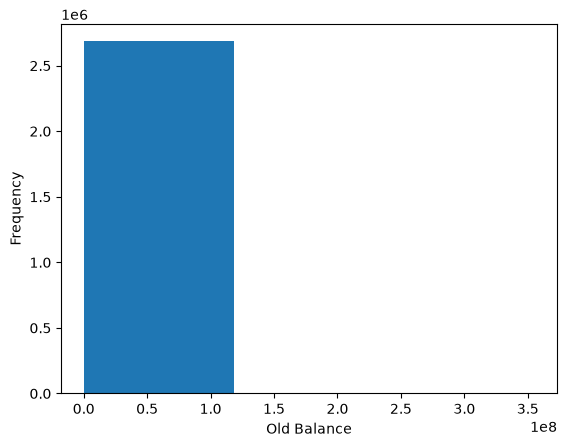

In [9]:
plt.hist(recipient_source["oldbalanceDest"],bins=3)
plt.xlabel("Old Balance")
plt.ylabel("Frequency")
plt.show()

In [10]:
def recipient_data_creator(recipient_source,n=1000):
    balance = recipient_source["oldbalanceDest"]
    positive_balance = balance[balance>0]
    log_balance = np.log1p(positive_balance)

    mu = log_balance.mean()
    sigma = log_balance.std()
    zero_probablity = (balance == 0).mean()
    is_zero = np.random.random(n) < zero_probablity
    positive_count = (~is_zero).sum()

    positive_data = np.random.lognormal(
        mean= mu,
        sigma= sigma,
        size=positive_count
    )
    zero_balences = np.zeros(is_zero.sum())
    synthectic_data = np.concatenate([zero_balences,positive_data])
    np.random.shuffle(synthectic_data)
    return synthectic_data


In [11]:
synthectic_data = recipient_data_creator(recipient_source)


In [12]:
recipient_df = pd.DataFrame({
    "recipient_id":[i for i in range(1,len(synthectic_data)+1)],
    "old_balance" : synthectic_data
})
recipient_final_dict = recipient_df.to_dict(orient="records")

In [13]:
recipients_col.insert_many(recipient_final_dict)

InsertManyResult([ObjectId('6ab40a1473faa90e6bd7b0b0'), ObjectId('6ab40a1473faa90e6bd7b0b1'), ObjectId('6ab40a1473faa90e6bd7b0b2'), ObjectId('6ab40a1473faa90e6bd7b0b3'), ObjectId('6ab40a1473faa90e6bd7b0b4'), ObjectId('6ab40a1473faa90e6bd7b0b5'), ObjectId('6ab40a1473faa90e6bd7b0b6'), ObjectId('6ab40a1473faa90e6bd7b0b7'), ObjectId('6ab40a1473faa90e6bd7b0b8'), ObjectId('6ab40a1473faa90e6bd7b0b9'), ObjectId('6ab40a1473faa90e6bd7b0ba'), ObjectId('6ab40a1473faa90e6bd7b0bb'), ObjectId('6ab40a1473faa90e6bd7b0bc'), ObjectId('6ab40a1473faa90e6bd7b0bd'), ObjectId('6ab40a1473faa90e6bd7b0be'), ObjectId('6ab40a1473faa90e6bd7b0bf'), ObjectId('6ab40a1473faa90e6bd7b0c0'), ObjectId('6ab40a1473faa90e6bd7b0c1'), ObjectId('6ab40a1473faa90e6bd7b0c2'), ObjectId('6ab40a1473faa90e6bd7b0c3'), ObjectId('6ab40a1473faa90e6bd7b0c4'), ObjectId('6ab40a1473faa90e6bd7b0c5'), ObjectId('6ab40a1473faa90e6bd7b0c6'), ObjectId('6ab40a1473faa90e6bd7b0c7'), ObjectId('6ab40a1473faa90e6bd7b0c8'), ObjectId('6ab40a1473faa90e6bd7b0

In [28]:
def ph_no_creator():
    num = 0
    while  num // 1000000000 == 0 :
        if num  == 0:
            num = np.random.randint(6,9)
        else:
            num = num * 10 + np.random.randint(0,9)
    return str(num)

In [31]:
recipients_col.update_many(
    {},
    { "$set" : {"recipient_ph":ph_no_creator()}}
)

UpdateResult({'n': 2000, 'electionId': ObjectId('7fffffff00000000000003bb'), 'opTime': {'ts': Timestamp(1790186920, 2006), 't': 955}, 'nModified': 2000, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1790186920, 2006), 'signature': {'hash': b"<\xfe\x02g\x08\xaek'\xeek@\xe4\x91\x1dXA\xfa/\xea\xf7", 'keyId': 7654947287134633990}}, 'operationTime': Timestamp(1790186920, 2006), 'updatedExisting': True}, acknowledged=True)

In [ ]:
recipients_col.update_many(
    {},
    {"$unset": {"recipient_id": ""}}
)

WriteError: BSON field 'collation.$unset' is an unknown field., full error: {'index': 0, 'code': 40415, 'errmsg': "BSON field 'collation.$unset' is an unknown field."}

In [27]:
db.list_collection_names()

['senders', 'recipients']